**Multiclass classifier**

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import kagglehub

path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Dataset path: /kaggle/input/ag-news-classification-dataset


In [3]:
df = pd.read_csv(os.path.join(path, "train.csv"), header=None)
df.columns = ["label", "title", "description"]

# Combine title + description
df["text"] = df["title"] + " " + df["description"]

df.head()

,label,title,description,text
0,Class Index,Title,Description,Title Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...


In [4]:
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120001 entries, 0 to 120000
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120001 non-null  object
 1   title        120001 non-null  object
 2   description  120001 non-null  object
 3   text         120001 non-null  object
dtypes: object(4)
memory usage: 3.7+ MB


,count
label,
3,30000
2,30000
4,30000
1,30000
Class Index,1


In [5]:
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120001 entries, 0 to 120000
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120001 non-null  object
 1   title        120001 non-null  object
 2   description  120001 non-null  object
 3   text         120001 non-null  object
dtypes: object(4)
memory usage: 3.7+ MB


,count
label,
3,30000
2,30000
4,30000
1,30000
Class Index,1


In [6]:
df = pd.read_csv(os.path.join(path, "train.csv"))

# Rename columns properly
df.columns = ["label", "title", "description"]

# Combine title + description
df["text"] = df["title"] + " " + df["description"]

df.head()

,label,title,description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [7]:
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
 3   text         120000 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.7+ MB


,count
label,
3,30000
4,30000
2,30000
1,30000


In [8]:
df["label"] = df["label"].astype(int)

In [9]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

df["category"] = df["label"].map(label_map)

df["category"].value_counts()

,count
category,
Business,30000
Sci/Tech,30000
Sports,30000
World,30000


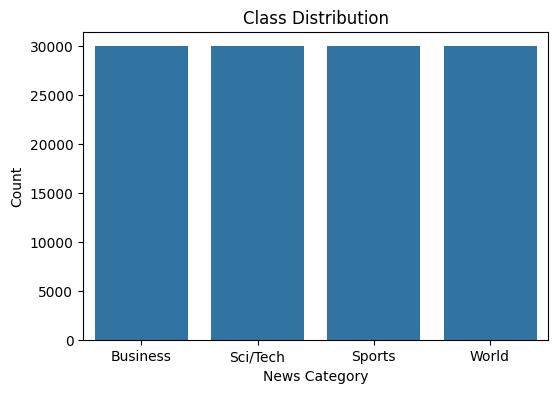

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="category", data=df)
plt.title("Class Distribution")
plt.xlabel("News Category")
plt.ylabel("Count")
plt.show()


In [11]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_preds = nb_model.predict(X_test_vec)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))

Naive Bayes Accuracy: 0.894375


In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

lr_preds = lr_model.predict(X_test_vec)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))

Logistic Regression Accuracy: 0.9077916666666667


In [15]:
print(classification_report(
    y_test,
    lr_preds,
    target_names=label_map.values()
))

              precision    recall  f1-score   support

       World       0.92      0.90      0.91      5956
      Sports       0.95      0.97      0.96      6058
    Business       0.87      0.88      0.87      5911
    Sci/Tech       0.89      0.88      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



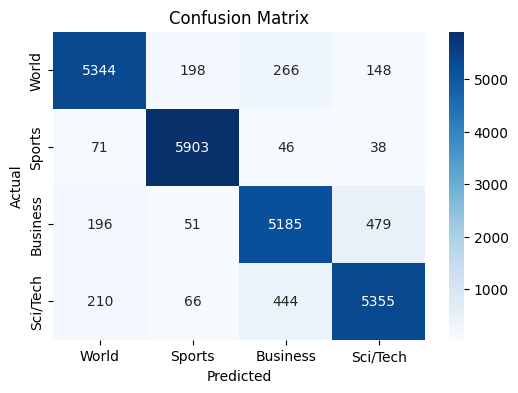

In [16]:
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
def predict_news(text):
    vec = vectorizer.transform([text])
    pred = lr_model.predict(vec)[0]
    return label_map[int(pred)]

In [21]:
import ipywidgets as widgets
from IPython.display import display

# 2. Create a widgets.Textarea for the news text input
input_text = widgets.Textarea(
    description='Enter News Text:',
    layout={'width': '500px', 'height': '150px'}
)

# 3. Create a widgets.Button
predict_button = widgets.Button(description='Predict News Category')

# 4. Create a widgets.Output widget to display the prediction results
output_area = widgets.Output()

# Function to handle button click
def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()
        news_text = input_text.value
        if news_text:
            prediction = predict_news(news_text)
            print(f"Predicted Category: {prediction}")
        else:
            print("Please enter some text for prediction.")

# Link the button click to the function
predict_button.on_click(on_predict_button_clicked)

# 5. Use display(input_text, predict_button, output_area) to show these widgets
display(input_text, predict_button, output_area)


Textarea(value='', description='Enter News Text:', layout=Layout(height='150px', width='500px'))

Button(description='Predict News Category', style=ButtonStyle())

Output()